# Synthesis Agent
This agent is responsible for the transformation process. It will use an `transformation.md` file to protocol each step in the process. In this file the agent writes a step-by-step plan for the transformation as well as some thoughts on the transformation process itself. There might be some challenges which can occur.

In [1]:
from pathlib import Path
import sys
import logging

logging.basicConfig(level=logging.DEBUG)

ROOT = Path.cwd().parent.parent
logging.info(f"Adding {ROOT} to Python path for imports in kernel.")
sys.path.insert(0, str(ROOT))  # ROOT, nicht SRC!

# Load config with changed env path
from src.config import Config
config = Config.get_instance(env_path=ROOT / ".env")


INFO:root:Adding /Users/lukas/Masterarbeit/agents/bxAgent to Python path for imports in kernel.
DEBUG:root:--- Loaded Configurations ---
DEBUG:root:Loaded BxAgentConfig: API_KEY=SecretStr('**********') BASE_URL='https://chat-1.ki-awz.iisys.de/api' BASE_MODEL='lisa-pro' CODING_MODEL='lisa-code-101'
DEBUG:root:Loaded LangFuseConfig: SECRET_KEY=SecretStr('**********') PUBLIC_KEY=SecretStr('**********') BASE_URL='http://localhost:3000'
DEBUG:root:Loaded WorkspaceConfig: PATH=PosixPath('/Users/lukas/Masterarbeit/agents/bxAgent/.bx-agent-workspace')
DEBUG:root:-----------------------------


After the module initialization, the agent should be build and the setup has to be prepared.

DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): mermaid.ink:443
DEBUG:urllib3.connectionpool:https://mermaid.ink:443 "GET /img/LS0tCmNvbmZpZzoKICBmbG93Y2hhcnQ6CiAgICBjdXJ2ZTogbGluZWFyCi0tLQpncmFwaCBURDsKCV9fc3RhcnRfXyhbPHA+X19zdGFydF9fPC9wPl0pOjo6Zmlyc3QKCW1vZGVsKG1vZGVsKQoJdG9vbHModG9vbHMpCglUb2RvTGlzdE1pZGRsZXdhcmVcMmVhZnRlcl9tb2RlbChUb2RvTGlzdE1pZGRsZXdhcmUuYWZ0ZXJfbW9kZWwpCglQYXRjaFRvb2xDYWxsc01pZGRsZXdhcmVcMmViZWZvcmVfYWdlbnQoUGF0Y2hUb29sQ2FsbHNNaWRkbGV3YXJlLmJlZm9yZV9hZ2VudCkKCV9fZW5kX18oWzxwPl9fZW5kX188L3A+XSk6OjpsYXN0CglQYXRjaFRvb2xDYWxsc01pZGRsZXdhcmVcMmViZWZvcmVfYWdlbnQgLS0+IG1vZGVsOwoJVG9kb0xpc3RNaWRkbGV3YXJlXDJlYWZ0ZXJfbW9kZWwgLS4tPiBfX2VuZF9fOwoJVG9kb0xpc3RNaWRkbGV3YXJlXDJlYWZ0ZXJfbW9kZWwgLS4tPiBtb2RlbDsKCVRvZG9MaXN0TWlkZGxld2FyZVwyZWFmdGVyX21vZGVsIC0uLT4gdG9vbHM7CglfX3N0YXJ0X18gLS0+IFBhdGNoVG9vbENhbGxzTWlkZGxld2FyZVwyZWJlZm9yZV9hZ2VudDsKCW1vZGVsIC0tPiBUb2RvTGlzdE1pZGRsZXdhcmVcMmVhZnRlcl9tb2RlbDsKCXRvb2xzIC0uLT4gX19lbmRfXzsKCXRvb2xzIC0uLT4gbW9kZWw7CgljbGFzc

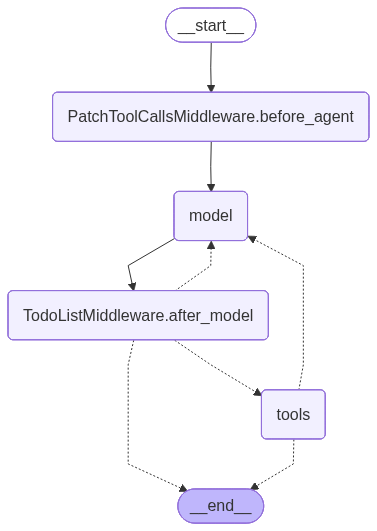

In [2]:
from src.agents.synthesis import build_synthesis_agent

agent = build_synthesis_agent()

config = {
    "configurable": {
        "thread_id": "some_id"
    }
}

agent

Lets test the agent to write a transformation about the Families2Person Problem. Exampleprompt is from "Prompting Bidirectional Model Transformations - The Good, The Bad and The Ugly"

In [ ]:
from langchain.messages import HumanMessage

prompt = (
    "The Families model stores Families (characterized by  their name) and corresponding FamilyMembers ( with given first name). FamilyMembers might take different roles within a Family (father, mother, sons, daughters). The Persons model on the other hand consists of a flat set of Persons, which are either Male or Female and which are characterized by their names and birthdays. FamilyMembers are transformed to Male persons, if they are attached to a Family via the father or sons reference and to Female persons otherwise. The person's name attribute is then a concatenation of the FamilyMember name and the Family name. The transformation of persons to FamilyMembers (and Families) works analogously."
    "Could you please also provide code for the opposite  direction? Please take into account that the transformation from the persons model to the families model should be configurable: One configuration parameter should indicate if persons should be added to already existing families with matching name. And the other configuration parameter indicates the role in which a person should be added. Prefer parent means, that if the father or mother role is not already taken in the family, the transformed person should be added as father or mother."
)

response = agent.invoke(
    input={
        "messages": [HumanMessage(content=prompt)]
    },
    config=config,
    version="v2"
)

print(response.value["messages"][-1].content)

DEBUG:openai._base_client:Request options: {'method': 'post', 'url': '/chat/completions', 'headers': {'X-Stainless-Raw-Response': 'true'}, 'files': None, 'idempotency_key': 'stainless-python-retry-28ec5b23-fda9-404f-a77d-d8cd0bfcd9f9', 'content': None, 'json_data': {'messages': [{'content': [{'type': 'text', 'text': '\nYou are the synthesis agent of the transformation process. \n\nYour task is to think about how to transform the source model into the target model with requirements given by the user. \nTo do this, you will need to analyze the source and target models, understand the given requirements, and then come up with a plan to transform the source model into the target model.\n\nSometimes it is not straightforward to transform the source model into the target model, and you have to decide between multiple options. \nIn this case, you should think step by step and protocol your thoughts in a clear and structured way.\n\nAlways protocol your thoughts with the tools: \n- update_tran

GraphOutput(value={'messages': [HumanMessage(content="The Families model stores Families (characterized by  their name) and corresponding FamilyMembers ( with given first name). FamilyMembers might take different roles within a Family (father, mother, sons, daughters). The Persons model on the other hand consists of a flat set of Persons, which are either Male or Female and which are characterized by their names and birthdays. FamilyMembers are transformed to Male persons, if they are attached to a Family via the father or sons reference and to Female persons otherwise. The person's name attribute is then a concatenation of the FamilyMember name and the Family name. The transformation of persons to FamilyMembers (and Families) works analogously.Could you please also provide code for the opposite  direction? Please take into account that the transformation from the persons model to the families model should be configurable: One configuration parameter should indicate if persons should b